## Laser Power vs Field Amplitude

$$
P_{las} = 10 \text{mV},  S=1\text{mm}^2 \implies E_0 = \sqrt{\frac{2 P_{las}}{c \varepsilon_0 S}}
$$

In [1]:
from MieSppForce.simulation import SimulationConfig, SweepRunner, ureg
import numpy as np
import matplotlib.pyplot as plt

Plas = 100 * ureg.milliwatt
d_source = 10 * ureg.micron
S = (d_source/2)**2 * np.pi

base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  130 * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi = np.pi/2,
    chi = np.pi/4,
    show_warnings=False,
    initial_field_type='plane_wave',
    amplitude=1
)

E0 = np.sqrt(2 *Plas/(base_config.c_const * base_config.eps0_const * S)).to('V/m')

setattr(base_config, 'amplitude', E0.magnitude)


/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
num_points = 100

dist_arr = np.linspace(2, 40, num_points)*ureg.nm

sweep_spp, _, _ = SweepRunner(base_config, 'dist', dist_arr, True, False, False, True).run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Van der Waals Forces between particle and plane (nonretarded regime)

$$
F^{VdW}_z = \frac{- 2 A_H R^3}{3 (2 R + d)^2 d^2}, \quad F^{VdW} \approx - \frac{A_H R}{6 d^2}
$$



$$
A_H \approx 1.5 \cdot 10^{-19} J
$$

In [17]:
print(FzVdW_aprox(25))

-5.199999999999999e-12 newton


-3.013717421124828e-11 newton


Text(0.5, 0, 'Distance (nm)')

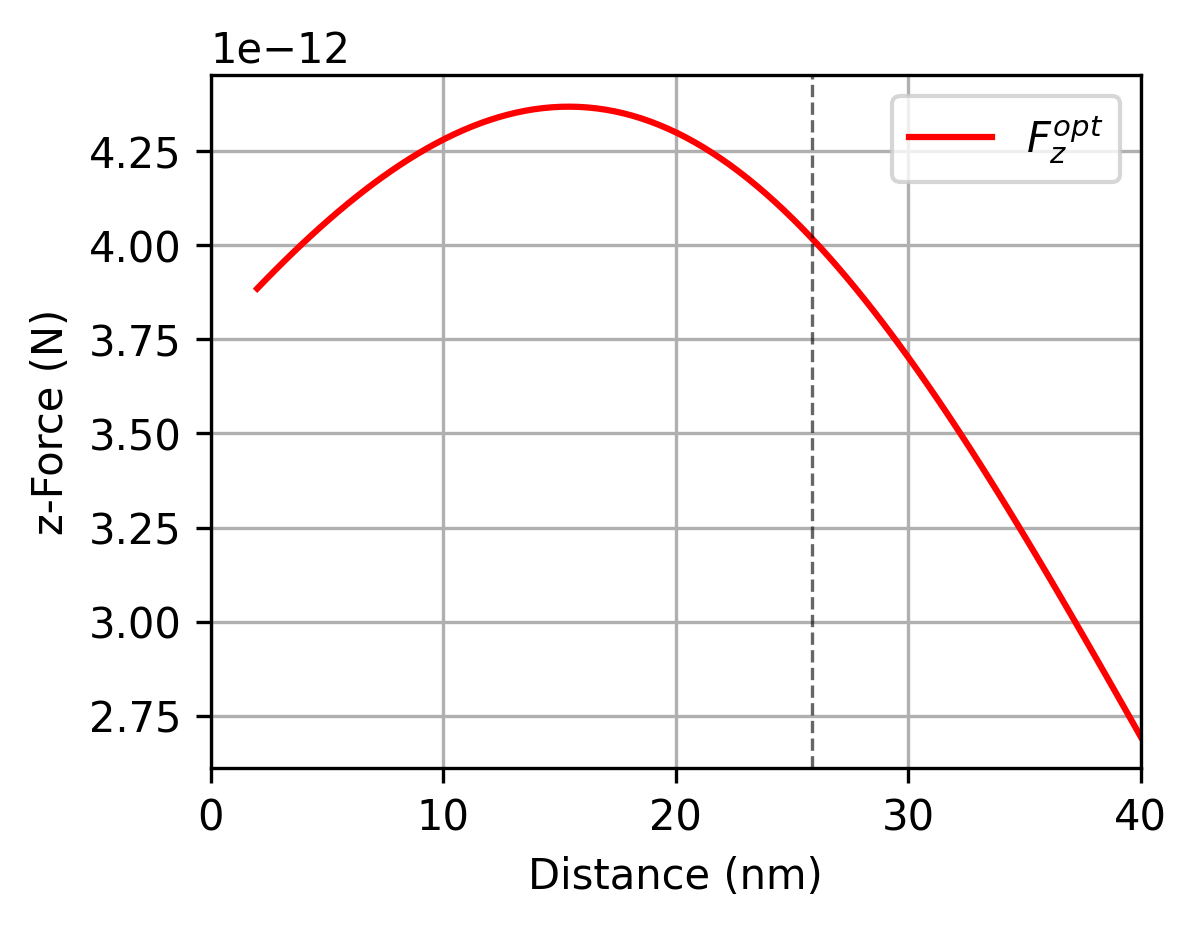

In [22]:
A_H = 1.5 * 1e-19 * ureg.J

def FzVdW(dist):
    dist_q = dist if hasattr(dist, "units") else dist * ureg.nm
    return (-2 * A_H * base_config.R**3 / (3 * (2 * base_config.R + dist_q)**2 * dist_q**2) ).to('N')

def FzVdW_aprox(dist):
    dist_q = dist if hasattr(dist, "units") else dist * ureg.nm
    return (-A_H * base_config.R / (6 * dist_q**2)).to('N')

print(FzVdW(10))

total_force = sweep_spp.Fz + FzVdW(dist_arr)
dist_nm = dist_arr.to('nm').magnitude
total_mag = total_force.to('N').magnitude
cross_idx = np.where(np.diff(np.sign(total_mag)) != 0)[0]
zero_nm = []
for i in cross_idx:
    x0, x1 = dist_nm[i], dist_nm[i + 1]
    y0, y1 = total_mag[i], total_mag[i + 1]
    xz = x0 if y1 == y0 else x0 - y0 * (x1 - x0) / (y1 - y0)
    zero_nm.append(xz)

plt.figure(figsize=(4,3), dpi=300)
#plt.plot(dist_arr, FzVdW(dist_arr), label='$F_z^{vdW}$', c='b', ls='--')
plt.plot(dist_arr, sweep_spp.Fz, label='$F_z^{opt}$', c='r')

#plt.plot(dist_arr, FzVdW_aprox(dist_arr), label='$F_z^{vdW}$ (aprx)', c='b', ls=':')

#plt.plot(dist_arr, total_force, label='$F_z^{opt} + F_z^{vdW}$', c='black')
for xz in zero_nm:
    plt.axvline(xz, color='k', linestyle='--', linewidth=0.8, alpha=0.6)

plt.xlim(0, 40)
plt.grid()
plt.legend()
plt.ylabel('z-Force (N)')
plt.xlabel('Distance (nm)')

In [5]:
from MieSppForce.simulation import SweepRunner2D
import pandas as pd

dist_values = np.linspace(5, 50, 30) * ureg.nm
R_values = np.linspace(100, 160, 30) * ureg.nm

base_config_map = SimulationConfig(
    wl=base_config.wl,
    R=R_values[0],
    dist=dist_values[0],
    angle=base_config.angle,
    chi=base_config.chi,
    psi=base_config.psi,
    show_warnings=False,
    initial_field_type=base_config.initial_field_type,
    amplitude=base_config.amplitude,
 )

runner_dist_R = SweepRunner2D(
    base_config_map,
    primary_param="dist",
    primary_values=dist_values,
    secondary_param="R",
    secondary_values=R_values,
    compute_dipoles=False,
    compute_diagram=False,
    compute_force=True,
    compute_fields=False,
    parallel_param="primary",
    enable_parallel=False,
 )

df_sweep_dist_R, _, _ = runner_dist_R.run(n_jobs=-1)



dist sweep: 100%|██████████| 30/30 [01:12<00:00,  2.43s/it]


In [7]:
heatmap_dist_r = df_sweep_dist_R.to_dataframe().copy()

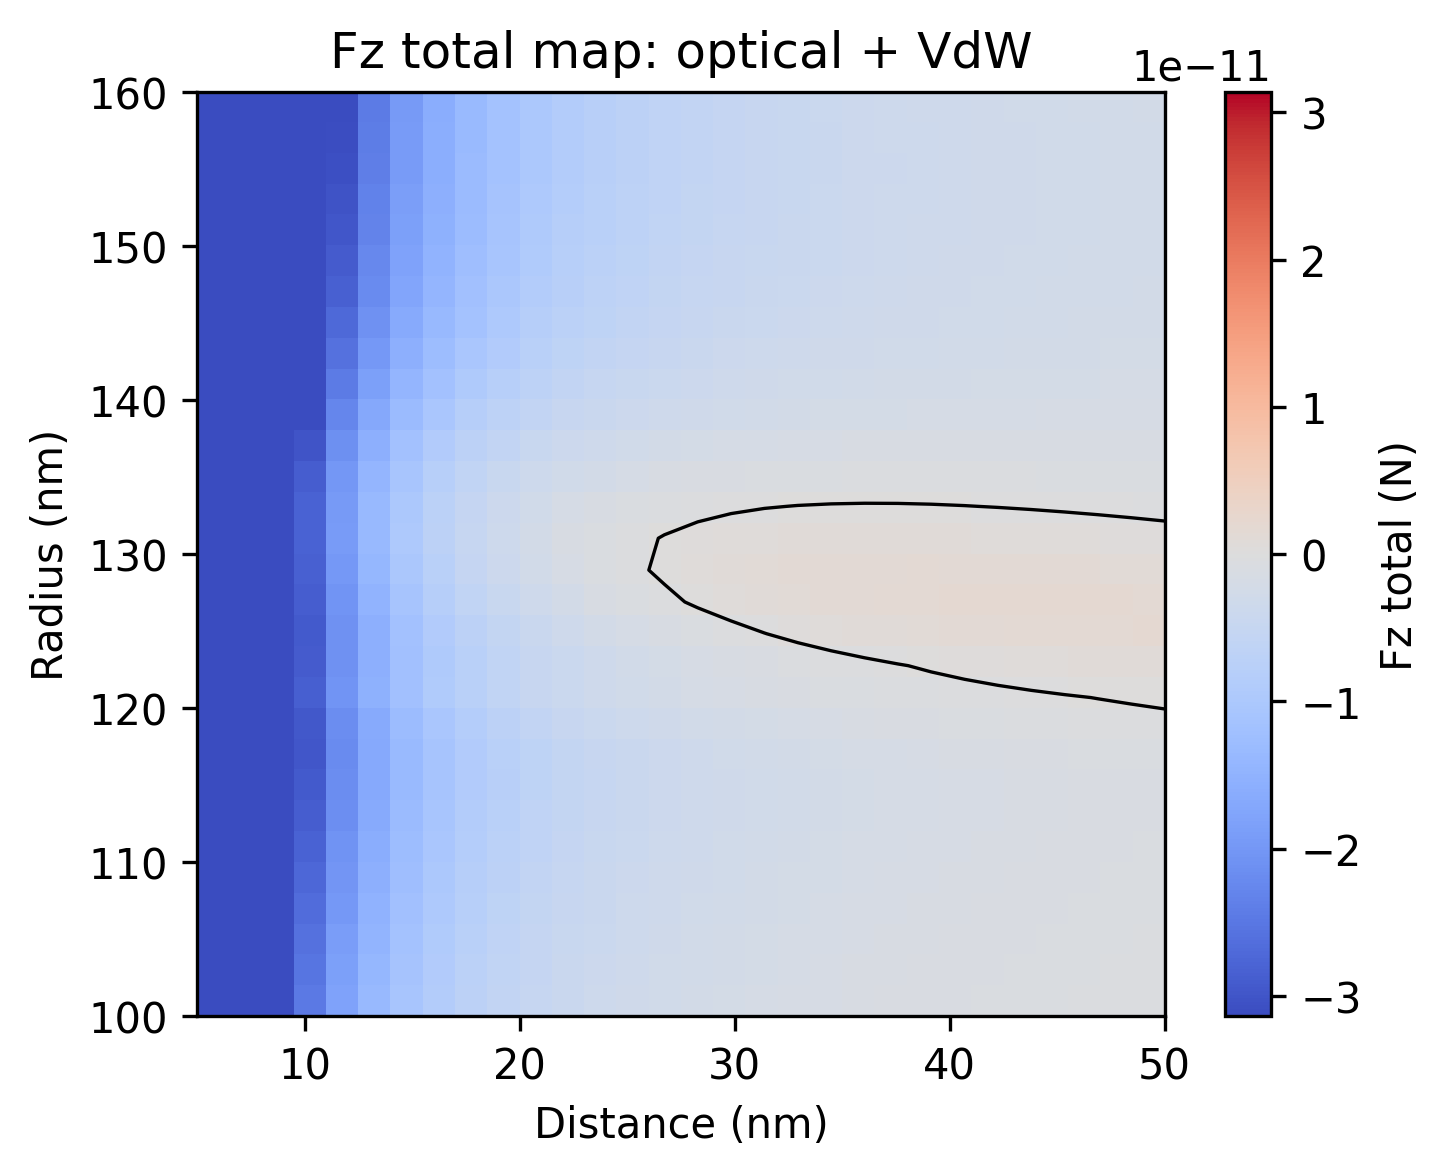

In [20]:
from matplotlib.colors import TwoSlopeNorm

df_raw = df_sweep_dist_R.to_dataframe().copy()
df_raw["Fz_N"] = df_raw["Fz"].apply(lambda v: v.to("N").magnitude)
df_grid = df_raw.pivot_table(index="dist", columns="R", values="Fz_N", aggfunc="mean")
df_grid = df_grid.sort_index().sort_index(axis=1)

dist_nm = np.array([d.to("nm").magnitude for d in df_grid.index])
R_nm = np.array([r.to("nm").magnitude for r in df_grid.columns])
Fz_opt = df_grid.values

dist_mesh, R_mesh = np.meshgrid(dist_nm, R_nm, indexing="ij")
dist_q = dist_mesh * ureg.nm
R_q = R_mesh * ureg.nm
Fz_vdw = (-2 * A_H * R_q**3 / (3 * (2 * R_q + dist_q)**2 * dist_q**2)).to("N").magnitude
Fz_total = Fz_opt + Fz_vdw

max_abs = np.nanmax(np.abs(Fz_total))/5
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

plt.figure(figsize=(5.2, 4.0), dpi=300)
img = plt.imshow(
    Fz_total.T,
    origin="lower",
    aspect="auto",
    extent=[dist_nm.min(), dist_nm.max(), R_nm.min(), R_nm.max()],
    cmap="coolwarm",
    norm=norm,
 )
plt.colorbar(img, label="Fz total (N)")
plt.contour(dist_nm, R_nm, Fz_total.T, levels=[0], colors="k", linewidths=0.8)
plt.xlabel("Distance (nm)")
plt.ylabel("Radius (nm)")
plt.title("Fz total map: optical + VdW")
plt.savefig("force_balance_map.png", dpi=300, bbox_inches='tight')